In [1]:
import os
import sys
import time
from pprint import pprint
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
from diffusionsim import climsim_utils as cut
from diffusionsim.trainers import DiffusionTrainer, ClimsimTrainer, u_q


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
from pprint import pprint
REF_BATCH_SIZE = 128
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
dataset_type = "climsim_train"
climsim_training = True
in_notebook = True
diffusers_available = False
def setup_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dconfig = tru.my_dconfig(data_vars, in_notebook, dataset_type, batch_size)
    dconfig.train_test_split = [0.01, 0.002]
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    #distloss_weights = [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [1.0, 1.0, 1.0, 1.0]
    target_variables_distloss = [68, 60, 73, 82]
    num_gaussians = [3, 2, 3, 2]
    unet_channel_dims = []
    unet_down_block_types = []

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': 1.0, 'distribution': 0, 'diffusion': diffloss_weights[i]}
        tconfig.distloss_var_ind = target_variables_distloss[i]
        tconfig.num_gaussians = num_gaussians[i]

        tconfig.max_T_sample = 51
        tconfig.phases = ['train', 'eval']

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels

        scheduler = tru.SchedulerParams()
        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        if(climsim_training):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_num_layers = len(mconfig.bl_hidden_dims)
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)


# Baselines: Distribution Loss

In [10]:
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
use_distribution_loss = True
use_diffusion_loss = False

In [11]:
exp_id = "DistLossTesting"
run_id = "multivar"
base_dir = os.path.join(exp_dir, exp_id)
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
dconfig.train_test_split = [0.01, 0.002]
dconfig.source = "gcsfs"

pprint(dconfig)

DataConfig(dataset_type='climsim_train',
           climsim_type='low-res-expanded',
           source='gcsfs',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [12]:
dutils = cut.setup_data_utils(dconfig.climsim_type, dconfig.source, dconfig.data_vars, 
                          use_tendencies=dconfig.use_tendencies, data_dir=dconfig.data_dir)

In [13]:
dataloaders, indices = data.load_dataloaders(dconfig, log=True, shuffle_indices=False)

In [14]:
dl, edl = dataloaders
print(len(dl.dataset))
batch = dl.dataset[2]

16


{"event": "get-batch start", "time": 1746478341.9399133, "pid": 184, "batch_idx": 2}
{"event": "get-batch end", "time": 1746478347.516028, "pid": 184, "batch_idx": 2, "duration": 5.576108932495117}


In [15]:
x, y = batch[0].to(device), batch[1].to(device)
x.shape, y.shape, x.device, y.device, y.requires_grad

(torch.Size([49152, 124]),
 torch.Size([49152, 128]),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 False)

In [16]:
#ximg, yimg = dl.dataset.make_image(x, y, False)

In [19]:
base_dir

'/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments/DistLossTesting'

In [20]:
exp_id, exp_dir

('DistLossTesting',
 '/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments')

In [21]:
model = tru.load_model_from_ckpt("trial0_dist_loss.pt", mconfigs[0], exp_id, exp_dir, baseline=True).to(device)

In [20]:
y_hat = model(x)
print(y_hat.shape, y_hat.device)

torch.Size([49152, 128]) cuda:0


In [21]:
#m = tru.build_baseline_model(mconfigs[0]).to(device)
loss_fn = torch.nn.MSELoss()


In [278]:
def distribution_loss(y_hat, y, tconfig, h=None):
    GMM = GaussianMixture(n_components=tconfig.num_gaussians)
    GMM.fit(y[:,tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 
    epsilon = 1e-7 # Ensure pi and var are positive and non-zero for stability
    pi = torch.clamp(pi, min=epsilon)
    var = torch.clamp(var, min=epsilon)

    if(h is None):
        with torch.no_grad():
            h = 2 * torch.max(var).item()

    bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
    batch_num = y_hat.shape[0] // bs
    ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
    mask = ix == jxy_hat.sh
    while mask.any():
        ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
        jx[mask] = torch.I(0, batch_num, (mask.sum(),))
        mask = ix == jx
    loss = 0
    for i,j in zip(ix, jx):
        y1 = y_hat[i*bs : (i+1)*bs, tconfig.distloss_var_ind]
        y2 = y_hat[j*bs : (j+1)*bs, tconfig.distloss_var_ind]
        loss += u_q(y1, y2, mu, var, pi, h).mean()
    return(loss)

In [35]:
def wasserstein_loss(y_hat, y, tconfig):
    # differentiable version since no library calls
    # Select specific variable
    N = tconfig.num_distloss_samples
    # Fit GMM on target distribution (non-differentiable, but that's ok)
    gmm = GaussianMixture(n_components=tconfig.num_gaussians)
    gmm.fit(y[:, tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))
    
    # use the GMM to draw samples from distribution
    mu = torch.tensor(gmm.means_.flatten(), dtype=torch.float32, device=y_hat.device)
    pi = torch.tensor(gmm.weights_.flatten(), dtype=torch.float32, device=y_hat.device)
    var = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float32, device=y_hat.device)
    z = torch.randn(N, dtype=torch.float32, device=y_hat.device) # reparameterization trick
    component_indices = torch.multinomial(pi, N, replacement=True)
    selected_mu = mu[component_indices]
    selected_std = torch.sqrt(var)[component_indices]
    gmm_samples = selected_mu + selected_std * z.squeeze() # compute quantiles
    # Compare quantiles
    q_vec = torch.linspace(0.001, 0.999, N, dtype=torch.float32, device=y_hat.device)
    gmm_quantiles = torch.quantile(gmm_samples, q_vec)
    yhat_quantiles = torch.quantile(y_hat, q_vec)
    wdl = torch.sum((gmm_quantiles - yhat_quantiles)**2)
    return wdl

In [36]:
tconfig = tconfigs[0]
tconfig.num_distloss_samples = 8
tconfig.distloss_bs = 1152 # NxN
VAR_IND = tconfig.distloss_var_ind
VAR_IND


68

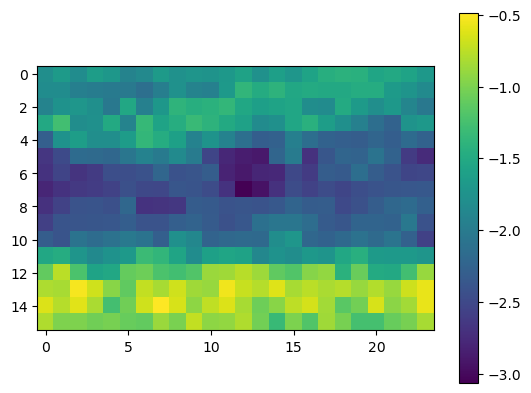

In [26]:
y_hat_img = imagify(y_hat, 128, dl.dataset.permute_indices)
plt.imshow(y_hat_img[8, :, :, VAR_IND].detach().cpu().numpy())
plt.colorbar()

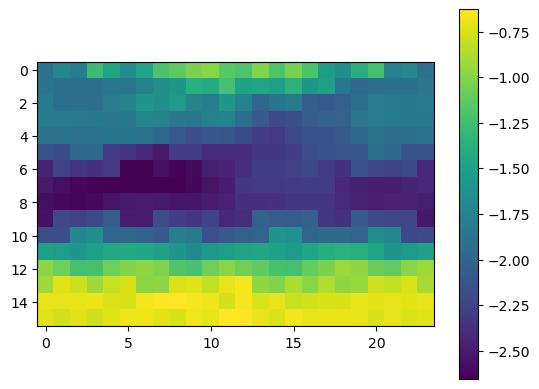

In [27]:
yimg = imagify(y, 128, dl.dataset.permute_indices)
plt.imshow(yimg[8, :, :, VAR_IND].detach().cpu().numpy())
plt.colorbar()

In [37]:
pprint(tconfigs[0])

TrainingConfig(exp_id='DistLossTesting',
               run_id='multivara',
               num_epochs=5,
               phases=['train', 'eval'],
               distributed_training=False,
               optimizer='adam',
               betas=(0.9, 0.999),
               lr_scheduler=None,
               learning_rate=0.0001,
               loss_weights={'diffusion': 1.0, 'distribution': 0, 'mse': 1.0},
               clip_gradients=True,
               max_T_sample=51,
               save_best_epoch=True,
               batch_logging_interval=32,
               batch_checkpoint_interval=50,
               log_gradients=False,
               push_to_hub=False,
               diffusion_loss_noise_level=10,
               distloss_type='ksd',
               num_gaussians=3,
               num_distloss_samples=8,
               distloss_bs=1152,
               distloss_var_ind=68)


In [55]:
wdl = wasserstein_loss(y_hat, y, tconfig)

In [32]:
dist_loss = distribution_loss(y_hat, y, tconfigs[0])

In [33]:
dist_loss

tensor(0.5278, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>)

In [44]:
ygrad = y_hat_leaf.grad[:, VAR_IND]
ygrad.shape

torch.Size([49152])

## Exploring Dist Loss

Helper Functions

In [99]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x,)

In [101]:
def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

def plot_gmm_distribution(gmm, data, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

### Gradient Comparison of MSE and Dist Loss

In [84]:
y_hat = model(x)

In [83]:
def get_loss_gradients(loss):
    for param in model.parameters():
        if(param.grad is not None):
            param.grad.zero_()
    loss.backward(retain_graph=True)
    gradients = {}
    for name, param in model.named_parameters():
        #  print(name, param.shape, param.grad.shape)
        gradients[name] = param.grad.detach().cpu().numpy()
    return(gradients)

In [86]:
mse_loss = loss_fn(model(x), y)
mse_gradients = get_loss_gradients(mse_loss)

dist_loss = distribution_loss(model(x), y, tconfigs[0])
dist_gradients = get_loss_gradients(dist_loss)

In [87]:
wdl_loss = wasserstein_loss(model(x), y, tconfigs[0])
wdl_gradients = get_loss_gradients(wdl_loss)

In [88]:
names = list(mse_gradients.keys())
for name in names:
    print(name, mse_gradients[name].shape, dist_gradients[name].shape, wdl_gradients[name].shape)
    print(name, mse_gradients[name].mean(), dist_gradients[name].mean(), wdl_gradients[name].mean(), "\n\n")


0.weight (256, 124) (256, 124) (256, 124)
0.weight 4.7008933e-05 0.015868487 -0.22414242 


0.bias (256,) (256,) (256,)
0.bias -0.0001390017 0.011203034 0.12169769 


2.weight (256, 256) (256, 256) (256, 256)
2.weight -4.1735104e-05 0.0058396826 0.099885784 


2.bias (256,) (256,) (256,)
2.bias -5.97272e-05 0.006425227 0.059429724 


4.weight (256, 256) (256, 256) (256, 256)
4.weight -2.3036337e-05 0.011356237 0.10843503 


4.bias (256,) (256,) (256,)
4.bias -3.4319062e-05 0.0076000635 0.04489117 


6.weight (128, 256) (128, 256) (128, 256)
6.weight -0.00019358488 -0.011582035 0.06183519 


6.bias (128,) (128,) (128,)
6.bias -9.947955e-05 -0.008730166 0.13223928 




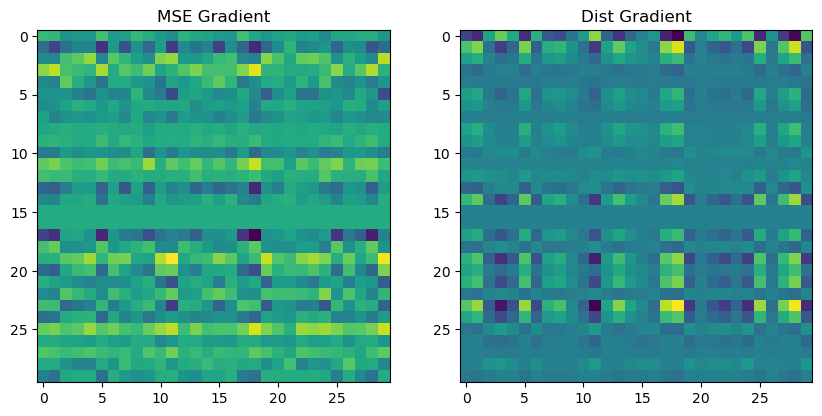

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mse_gradients[names[2]][40:70, :30])
axes[0].set_title('MSE Gradient')
axes[1].imshow(dist_gradients[names[2]][40:70, :30])
axes[1].set_title('Dist Gradient')
plt.show()


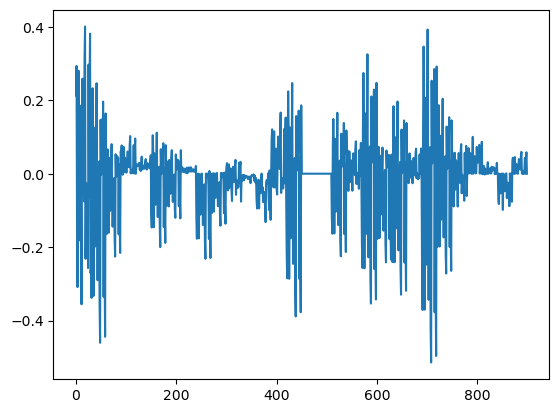

In [90]:
plt.plot((mse_gradients[names[2]][40:70, :30] - dist_gradients[names[2]][40:70, :30]).flatten())
plt.show()

### Making sure it works

In [129]:
y_hat_leaf = y_hat.detach().cpu().numpy().copy()
y_hat_leaf = torch.tensor(y_hat_leaf, dtype=torch.float32, device=device, requires_grad=True)

In [151]:
VAR_IND = 81
tconfig.distloss_var_ind = VAR_IND

In [113]:
y_sel = y[:, VAR_IND]
y_hat_sel = y_hat_leaf[:, VAR_IND]

In [82]:
GMM = GaussianMixture(n_components=tconfig.num_gaussians)
GMM.fit(y_sel.detach().cpu().numpy().reshape(-1, 1))

GaussianMixture(n_components=3)

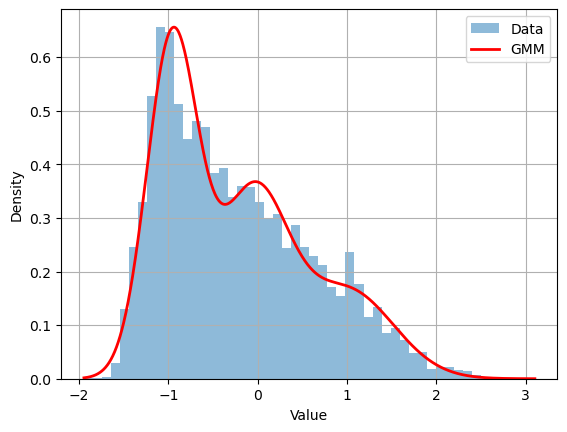

In [131]:
d=plot_gmm_distribution(GMM, y_sel)

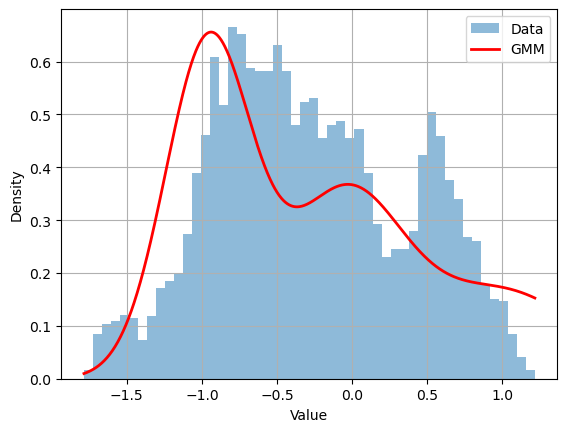

In [132]:
d=plot_gmm_distribution(GMM, y_hat_sel)

### Wasserstein Loss
$$W_2(P, Q)^2 = \int_0^1 |F^{-1}_P(t) - F^{-1}_Q(t)|^2 dt$$

- Approximate inverse CDF with quantile plot, i.e. $F^{-1}(p) = x \leftrightarrow$ $Pr(X \leq x) = p$
- Inverse because normal CDF is "for given value x, what is the probability $p(X \leq x)$

In [135]:
y.shape, y_hat.shape

(torch.Size([49152, 128]), torch.Size([49152, 128]))

In [136]:
tconfig.distloss_var_ind

68

In [137]:
GMM = GaussianMixture(n_components=tconfigs[0].num_gaussians)

In [138]:
GMM.fit(y[:, tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))

GaussianMixture(n_components=3)

In [ ]:
GMM.sample

In [155]:
n_points = 1000
xsamples = torch.linspace(-4, 0, n_points)
xdensity = eval_density(GMM, xsamples, training=False, return_components=False)[0][:,0]

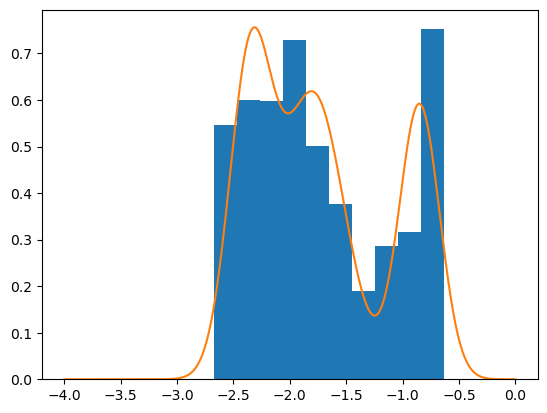

In [156]:
plt.hist(y[:, tconfig.distloss_var_ind].detach().cpu().numpy(), density=True)
plt.plot(xsamples, xdensity)

In [157]:
gmm_samples = GMM.sample(1000)[0][:,0]
gmm_samples.shape

(1000,)

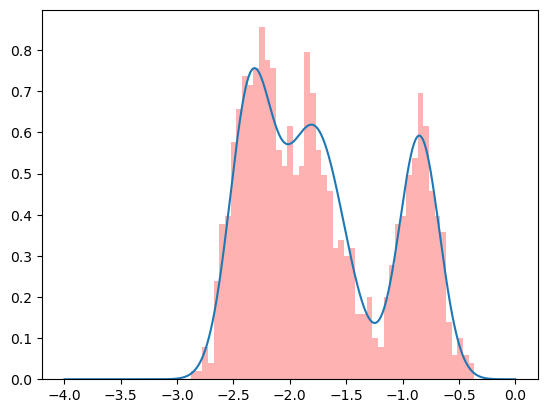

In [162]:
plt.hist(gmm_samples, bins=50, alpha=0.3, density=True, color='red')
plt.plot(xsamples, xdensity)
plt.show()

In [164]:
q_vec = torch.arange(1, 1000, dtype=torch.float64) / 1000
gmm_quantiles = np.quantile(gmm_samples, q_vec)
yhat_quantiles = np.quantile(y_hat[:, tconfig.distloss_var_ind].detach().cpu().numpy(), q_vec)

In [165]:
np.percentile(gmm_samples, 90) # the value x st 90% of the samples are less than x

np.float64(-0.7919000955865458)

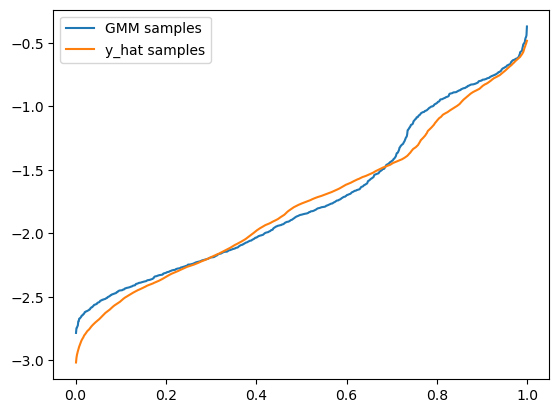

In [166]:
plt.plot(q_vec, gmm_quantiles, label='GMM samples') # inverse CDF (value over prob, not prob over value)
plt.plot(q_vec, yhat_quantiles, label='y_hat samples')
plt.legend()
plt.show()

In [171]:
np.mean(gmm_quantiles - yhat_quantiles) ** 2

np.float64(0.0006752542369596659)

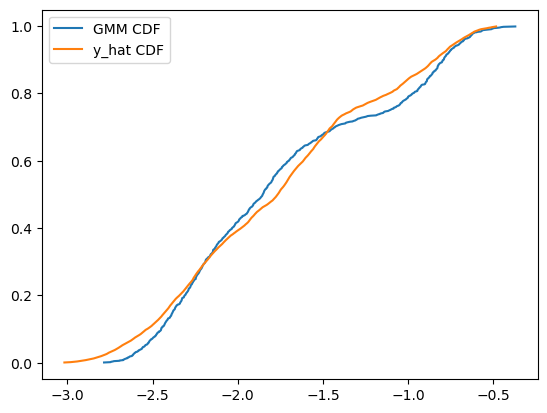

In [172]:
plt.plot(gmm_quantiles, q_vec, label='GMM CDF') # CDF
plt.plot(yhat_quantiles, q_vec, label='y_hat CDF')
plt.legend()
plt.show()


In [ ]:
q_vec = torch.arange(1, 1000, dtype=torch.float64) / 1000
def wasserstein_loss_no_grad(y_hat, y, VAR_IND=VAR_IND):
    y_hat, y = y_hat[:, VAR_IND], y[:, VAR_IND]
    gmm = GaussianMixture(n_components=2)
    gmm.fit(y.detach().cpu().numpy().reshape(-1, 1))
    
    gmm_samples = gmm.sample(1000)[0][:,0]
    gmm_quantiles = np.quantile(gmm_samples, q_vec)
    yhat_quantiles = np.quantile(y_hat.detach().cpu().numpy(), q_vec)

    wdl = np.sum((gmm_quantiles - yhat_quantiles)**2)
    return(wdl)

def wasserstein_loss(y_hat, y, tconfig, verbose=True):
    # differentiable version since no library calls
    # Select specific variable
    N = tconfig.num_distloss_samples
    # Fit GMM on target distribution (non-differentiable, but that's ok)
    gmm = GaussianMixture(n_components=tconfig.num_gaussians)
    gmm.fit(y[:, tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))
    
    # use the GMM to draw samples from distribution
    mu = torch.tensor(gmm.means_.flatten(), dtype=torch.float32, device=y_hat.device)
    pi = torch.tensor(gmm.weights_.flatten(), dtype=torch.float32, device=y_hat.device)
    var = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float32, device=y_hat.device)
    z = torch.randn(N, dtype=torch.float32, device=y_hat.device) # reparameterization trick
    component_indices = torch.multinomial(pi, N, replacement=True)
    selected_mu = mu[component_indices]
    selected_std = torch.sqrt(var)[component_indices]
    gmm_samples = selected_mu + selected_std * z.squeeze() # compute quantiles
    # Compare quantiles
    q_vec = torch.linspace(0.001, 0.999, N, dtype=torch.float32, device=y_hat.device)
    gmm_quantiles = torch.quantile(gmm_samples, q_vec)
    yhat_quantiles = torch.quantile(y_hat[:, tconfig.distloss_var_ind], q_vec)
    wdl = torch.sum((gmm_quantiles - yhat_quantiles)**2)
    return wdl

wasserstein_loss(y_hat, y, tconfigs[0])


In [407]:
[t.distloss_var_ind for t in tconfigs]

[68, 60, 73, 82]

In [367]:
tconfig.num_distloss_samples = 20
tconfig.distloss_bs = 4*384
pprint(tconfig)

TrainingConfig(exp_id='DistLossTesting',
               run_id='multivara',
               num_epochs=5,
               phases=['train', 'eval'],
               distributed_training=False,
               optimizer='adam',
               betas=(0.9, 0.999),
               lr_scheduler=None,
               learning_rate=0.0001,
               loss_weights={'diffusion': 1.0, 'distribution': 0, 'mse': 1.0},
               clip_gradients=True,
               max_T_sample=51,
               save_best_epoch=True,
               batch_logging_interval=32,
               batch_checkpoint_interval=50,
               log_gradients=False,
               push_to_hub=False,
               diffusion_loss_noise_level=10,
               distloss_type='ksd',
               num_gaussians=3,
               num_distloss_samples=20,
               distloss_bs=1536,
               distloss_var_ind=68)


In [ ]:
var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:]
h1 = 2 * torch.max(var).item()
h = torch.std(y_calibrated[:,VAR_IND]).item()
h, h1

In [400]:
lamb = 0.001
VAR_IND = 68
q_vec = torch.arange(1, 1000, dtype=torch.float64) / 1000
GMM = GaussianMixture(n_components=3)
GMM.fit(y[:,tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))
gmm_samples = GMM.sample(1000)[0][:,0]
quantiles = np.quantile(gmm_samples, q_vec)


def simple_wasserstein(y_cal):
    y_cal = y_cal[:, VAR_IND].detach().cpu().clone().numpy()
    return(np.sum((np.quantile(y_cal, q_vec) - quantiles) ** 2))



def KSD_calibration(y_hat, lamb, h=h, verbose=False):
    ksds = []
    wdls = []
    early_stopping_patience = 0
    tolerance = 10
    
    y_calibrated = y_hat.detach().cpu().numpy().copy()
    y_calibrated = torch.tensor(y_calibrated, dtype=torch.float32, device=device, requires_grad=True)
    
    best_results = {'dist_wdl': simple_wasserstein(y_calibrated),
                    'best_test_y_hat': y_calibrated}
    
    for step in range(100):
        ksd = distribution_loss(y_calibrated, y, tconfig)
        ksds.append(ksd.item())
        ksd.backward()
        if y_calibrated.grad is None:
            print(f"Gradient is None at {step=}")
            break
        else:
            gradient = y_calibrated.grad[:,VAR_IND].detach().clone()
        #gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_calibrated[:, VAR_IND])
        with torch.no_grad():
            gradient = torch.clip(gradient, -5 * torch.std(gradient), 5 * torch.std(gradient))
            if(verbose):
                print(f"Gradient RMS: {torch.sqrt(torch.mean(gradient ** 2)).item()}")
                print(f"Y std: {torch.std(y_calibrated).item()}")
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_calibrated)
            y_calibrated[:,VAR_IND] = y_calibrated[:,VAR_IND] - lamb * gradient
        #y_calibrated.grad.zero_()
        y_calibrated = y_calibrated.detach().requires_grad_(True)  # Key fix: reattach to computational graph
        
        if(y_calibrated.grad is not None):
            y_calibrated.grad.zero_()
    
        dist_WDL = simple_wasserstein(y_calibrated)
        wdls.append(dist_WDL.item())    
        if dist_WDL < best_results['dist_wdl']:  # Update the best results if improvement
            best_results = {
                'dist_wdl': dist_WDL,
                'best_test_y_hat': y_calibrated
            }
            early_stopping_patience = 0  # Reset patience if there's improvement
        else:
            early_stopping_patience += 1  # Increment patience if no improvement
            print(f"Patience is waning at val {early_stopping_patience}, {step=}")
    
        if early_stopping_patience >= tolerance:
            print(f"Early stopping at step {step} for tolerance {tolerance} due to no improvement in dist_WDL.")
            break

        return(ksds, wdls, best_results, 


Gradient RMS: 0.014179573394358158
Y std: 2.034560203552246
Gradient RMS: 0.013182129710912704
Y std: 2.0345590114593506
Gradient RMS: 0.013160914182662964
Y std: 2.034558057785034
Gradient RMS: 0.011816557496786118
Y std: 2.0345566272735596
Gradient RMS: 0.01085225772112608
Y std: 2.034555435180664
Gradient RMS: 0.011450594291090965
Y std: 2.0345542430877686
Gradient RMS: 0.010349305346608162
Y std: 2.034553050994873
Gradient RMS: 0.009319974109530449
Y std: 2.0345516204833984
Gradient RMS: 0.009029434062540531
Y std: 2.0345499515533447
Gradient RMS: 0.009057397022843361
Y std: 2.034548282623291
Gradient RMS: 0.008821272291243076
Y std: 2.0345468521118164
Gradient RMS: 0.008903409354388714
Y std: 2.0345451831817627
Gradient RMS: 0.009238607250154018
Y std: 2.034543514251709
Gradient RMS: 0.007976515218615532
Y std: 2.0345420837402344
Gradient RMS: 0.007458886131644249
Y std: 2.0345404148101807
Gradient RMS: 0.007850081659853458
Y std: 2.034538984298706
Gradient RMS: 0.0080566359683871

In [403]:
wasserstein_cal[lamb] = wdls

In [396]:
wasserstein_cal.keys()

dict_keys([0.01, 0.001, 0.1, 0.005])

[]

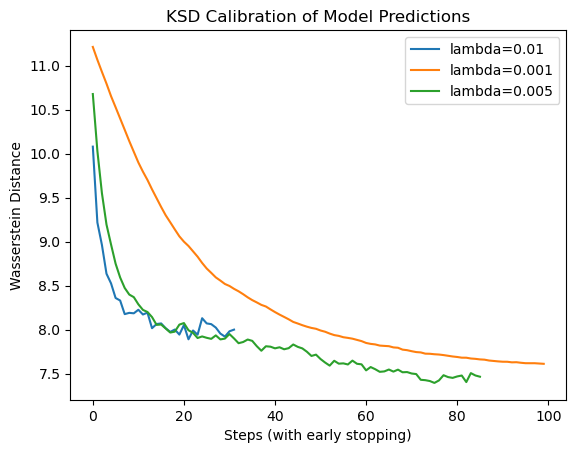

In [405]:
for lamb in wasserstein_cal.keys():
    if(lamb < 0.099):
        plt.plot(wasserstein_cal[lamb], label=f'lambda={lamb}')
plt.legend()
plt.title("KSD Calibration of Model Predictions")
plt.xlabel("Steps (with early stopping)")
plt.ylabel("Wasserstein Distance")
plt.plot()

In [333]:
gradient.max(), gradient.min(), gradient.std(), torch.abs(gradient[gradient!=0]).median()

(tensor(0.0559), tensor(-0.0806), tensor(0.0143), tensor(0.0100))

### Selecting Var

In [54]:
mlo = dl.dataset.mlo

In [65]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x,)

In [66]:
def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

def plot_gmm_distribution(gmm, data, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

In [52]:
from ipywidgets import interact, widgets
from matplotlib import pyplot as plt
def variable_dist_viewer(y, cmap='viridis', dataset=dataloaders[0].dataset):
    y = y.detach().cpu().numpy()
    # Define interactive plot function
    def plot_image(variable):
        hist(y[:, variable], title=f"Variable {dataset.mlo[variable].item()} from y_test")

        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = y.shape
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
variable_dist_viewer(y)

interactive(children=(IntSlider(value=0, description='Variable:', max=127), Output()), _dom_classes=('widget-i…

: 

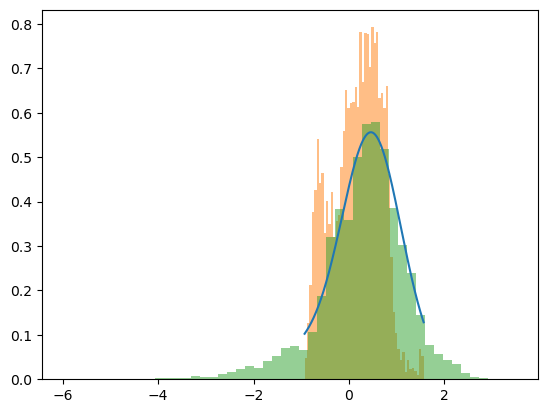

interactive(children=(IntSlider(value=0, description='Variable:', max=127), Output()), _dom_classes=('widget-i…

In [53]:

from ipywidgets import interact, widgets
from matplotlib import pyplot as plt
def discrepancy_viewer(y, cmap='viridis'):
    # Define interactive plot function
    gmm = GaussianMixture(n_components=2)
    def plot_image(variable):
        y_sel = y[:, variable].detach().cpu().numpy()
        y_hat_sel = y_hat[:, variable].detach().cpu().numpy()
        gmm.fit(y_sel.reshape(-1,1))
        x = torch.linspace(y_hat_sel.min(), y_hat_sel.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(y_hat_sel, density=True, label='histogram of y_hat', bins=50, alpha=0.5)
        plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Variable {mlo[variable].item()}")
        plt.legend()
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = y.shape
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
discrepancy_viewer(y, y_hat)

In [89]:
VAR_IND = 68

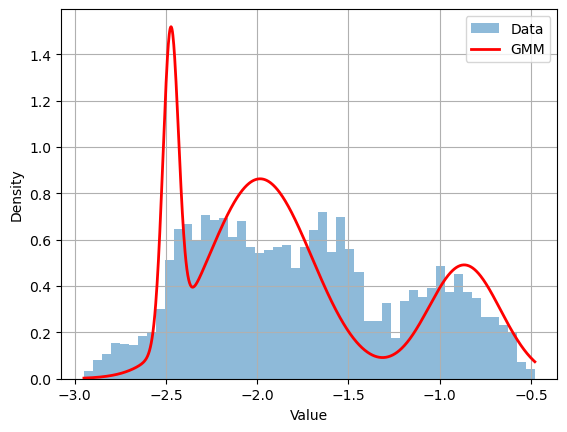

In [90]:
gmm = GaussianMixture(n_components=3)
gmm.fit(y[:,VAR_IND].cpu().numpy().reshape(-1,1))
densities = plot_gmm_distribution(gmm, y_hat[:,VAR_IND].detach().cpu().numpy(), components=False)

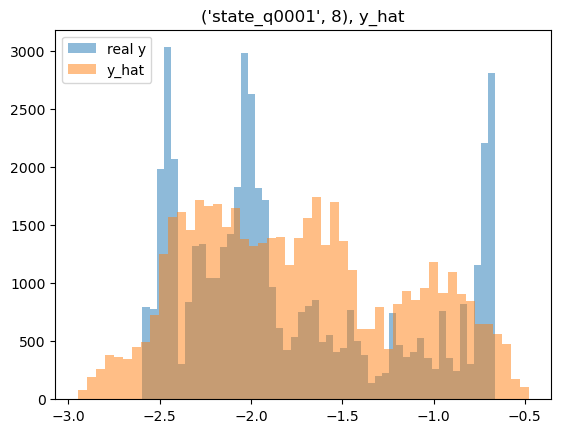

In [91]:
hist(y[:,VAR_IND], title=f'{mlo[VAR_IND].item()}, real y', bins=50, alpha=0.5, label='real y')
hist(y_hat[:,VAR_IND], title=f'{mlo[VAR_IND].item()}, y_hat', bins=50, alpha=0.5, label='y_hat')

Based on the above analyis, we select variable 68, Specific Humidity to target with distribution loss

In [93]:
VAR_IND, mlo[VAR_IND].item()

(68, ('state_q0001', 8))

In [96]:
model, y.shape, y_hat.shape, y.device, y_hat.device, y_hat.requires_grad

(Sequential(
   (0): Linear(in_features=124, out_features=256, bias=True)
   (1): ReLU()
   (2): Linear(in_features=256, out_features=256, bias=True)
   (3): ReLU()
   (4): Linear(in_features=256, out_features=256, bias=True)
   (5): ReLU()
   (6): Linear(in_features=256, out_features=128, bias=True)
 ),
 torch.Size([49152, 128]),
 torch.Size([49152, 128]),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 True)

### Defining Distribution Loss

In [38]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x)

def NLL(GMM, x):
    densities = eval_density(GMM, x)
    return(-torch.mean(torch.log(densities)))

def NLL_loss(y, yhat, var_ind=59, nc=2):
    y_sel = y[:, [var_ind]]
    gmm = GaussianMixture(n_components=nc)
    gmm.fit(y_sel.cpu().numpy())

    return(NLL(gmm, yhat[:, [var_ind]]))


NLL_loss(y, y_hat)

tensor(11.2448, device='cuda:0', dtype=torch.float64, grad_fn=<NegBackward0>)

In [39]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True))
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()


def u_q(x_1, x_2, GMM, h=1, debug=False):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 

    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
    if debug:
        term_1 = torch.outer(sq1, sq2) * kernel_matrix
        term_2 = sq1.reshape(-1,1) * diffs * kernel_matrix / h**2
        term_3 = -1 * sq2.reshape(1, -1) * diffs * kernel_matrix / h**2    
        term_4 =  (h**-2 - h**-4 * diffs ** 2) * kernel_matrix
        return term_1, term_2, term_3, term_4, kernel_matrix
    
    return(( torch.outer(sq1, sq2) + 
            (sq1.reshape(-1,1) * diffs - sq2.reshape(1, -1) * diffs)/h**2 + 
            (h**-2 - h**-4 * diffs ** 2)) * kernel_matrix)

In [65]:
bs = 6144
VAR_IND = 68
def get_i(x, i):
    return(x[i*bs : (i+1)*bs, VAR_IND])

def distribution_loss(y_hat, y, K=2, VAR_IND=68, n_samples=4, h=1, bs=3072):
    # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=K)
    gmm.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))

    with torch.no_grad():
        h = 3 * torch.std(y).item()

    ix, jx = torch.randint(0, y_hat.shape[0] // bs, (n_samples,)), torch.randint(0, y_hat.shape[0] // bs, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, y_hat.shape[0] // bs, (mask.sum(),))
        jx[mask] = torch.randint(0, y_hat.shape[0] // bs, (mask.sum(),))
        mask = ix == jx
    loss = 0
    for i,j in zip(ix, jx):
        y1 = get_i(y_hat, i)
        y2 = get_i(y_hat, j)
        loss += u_q(y1, y2, gmm, h, debug=False).mean()
    return(loss / n_samples)

In [71]:
type( torch.max(var).item() )

float

In [66]:
gmm = GaussianMixture(n_components=2)
gmm.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))

GaussianMixture(n_components=2)

In [67]:
distribution_loss(y_hat, y)

tensor(0.0008, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>)

### KSD Implementation

Inputs: $y$ and $\hat{y}$, tensors of size $(bs,)$

Output: Loss scalar

1. Train Gaussian Mixture Model to create knowledge distribution $q$. Predictions $\hat{y}$ from model assumed $\sim p$ from which we have $N:= bs // 384$ samples
2. Define $u_q$ function that takes in 2 samples from $p, (\hat{y})$ and returns kernel discrepancy function $$u_q(x, x') := s_q(x) k(x, x') s_q(x') + s_q(x) \nabla_{x'} k(x, x') + s_q(x')  \nabla_{x} k(x,x') +  \nabla_{x,x'} k(x,x')$$

Here we use a Gaussian kernel, so $k(x,x') = \exp(\dfrac{-(x_1-x_2)^2}{2h})$
Since our knowledge distribution $q$ is a Gaussian mixture model, our score function $$s_q(x) = - \sum_{k=1}^K \dfrac{\pi_k \mathcal{N}(x|\mu_k, \sigma_k^2)}{q(x)} \cdot \dfrac{x-\mu_k}{\sigma_k^2} = - \dfrac{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2}) \cdot \dfrac{x-\mu_k}{\sigma_k^2}  }{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2})}$$

3. $U_q := \dfrac{1}{n(n-1)} \sum_{i,j} u_q(x_i, x_j)$

4. Since calculations are all done in Pytorch, can compute $D(\hat{y}) := \dfrac{\partial U_p(\hat{y}_{1:n})}{\partial \hat{y}_i}$

#### Creating function step by step

In [272]:
def plot(x):
    if(isinstance(x, torch.Tensor)):
        x = x.detach().cpu().numpy()
    plt.plot(x)
    plt.show()


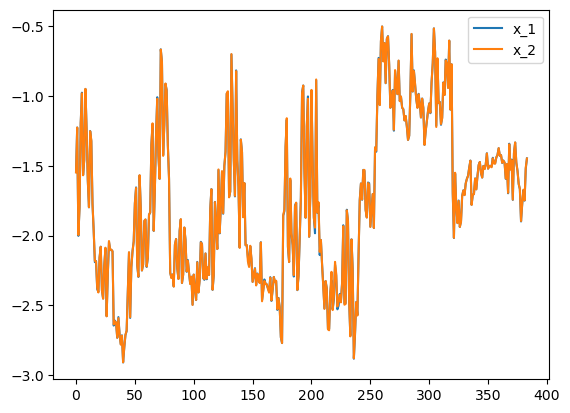

In [19]:
def get_i(x, i, bs=384, var_ind=68):
    return(x[i*bs:(i+1)*bs, var_ind])
x_1 = get_i(y_hat, 0)
x_2 = get_i(y_hat, 1)
x_1.shape, x_2.shape, x_1.device

plt.plot(x_1.detach().cpu().numpy(), label='x_1')
plt.plot(x_2.detach().cpu().numpy(), label='x_2')
plt.legend()
plt.show()


In [21]:
VAR_IND = 68
GMM = GaussianMixture(n_components=3)
GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1,1))

GaussianMixture(n_components=3)

In [41]:
y.shape[0] // 384

128

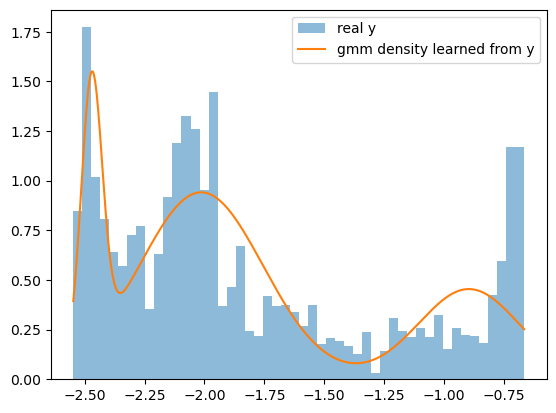

In [ ]:
x = torch.linspace(y[:,VAR_IND].min(), y[:,VAR_IND].max(), 1000)
densities = eval_density(GMM, x, training=False)
plt.hist(y[:,VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='real y')
plt.plot(x, densities, label='gmm density learned from y')
plt.legend()
plt.show()


In [28]:
mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (nc, d=1 flattened)
pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,)
var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 


mu.shape, pi.shape, var.shape


(torch.Size([1, 3]), torch.Size([1, 3]), torch.Size([1, 3]))

Broadcasting trick: 

By making $x_1$ size (N,1) and $\mu$ (1, K), we allow addition and subtraction operations that create (N,K) size tensors where $M_{ik} = x_i - \mu_k$


In [29]:
x_1.shape
comp_wise = x_1[:,None] - mu
comp_wise[26, 2].item(), (x_1[26] - mu[0,2]).item()

(-0.10810972447950462, -0.10810972447950462)

In [30]:
epsilon = 1e-9 
pi = torch.clamp(pi, min=epsilon)
var = torch.clamp(var, min=epsilon)
mu, pi, var



(tensor([[-2.0135, -0.8966, -2.4701]], device='cuda:0', dtype=torch.float64),
 tensor([[0.6104, 0.2421, 0.1475]], device='cuda:0', dtype=torch.float64),
 tensor([[0.0669, 0.0452, 0.0019]], device='cuda:0', dtype=torch.float64))

$$q(x) = \sum_{k=1}^K \dfrac{\pi_k}{\sigma_k \sqrt{2\pi}} \exp(-\dfrac{(x-\mu_k)^2}{2\sigma^2}) $$

$$s_q(x) = - \sum_{k=1}^K \dfrac{\pi_k \mathcal{N}(x|\mu_k, \sigma_k^2)}{q(x)} \cdot \dfrac{x-\mu_k}{\sigma_k^2}$$

In [31]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    log_qx = torch.logsumexp(log_probs, dim=1, keepdim=True)
    qx = torch.exp(log_qx)
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

In [32]:
log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x_1[:,None] - mu) ** 2 / (2 * var)
log_qx = torch.logsumexp(log_probs, dim=1, keepdim=True)
qx = torch.exp(log_qx)
(qx - eval_density(GMM, x_1)).abs().sum()

tensor(1.8867e-14, device='cuda:0', dtype=torch.float64,
       grad_fn=<SumBackward0>)

torch.Size([384]) torch.Size([384])


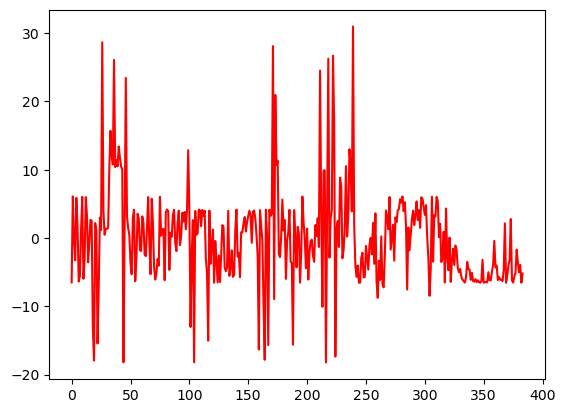

In [33]:
score_function(x_1, mu, var, pi).shape, score_function(x_2, mu, var, pi).shape
sq1 = score_function(x_1, mu, var, pi)
sq2 = score_function(x_2, mu, var, pi)
print(sq1.shape, sq2.shape)
plt.plot(sq1.detach().cpu().numpy(), label='sq1', color='red')

#### Vectorizing Implementation

$\cdot$ denotes matrix mult, $\times$ denotes element wise mult 

Goal: Matrix $M_{ij} := u_q(x_i, x'_j)$

Term 1: $s_q(x) k(x, x') s_q(x')$ - accomplished by $(s_q(x) \cdot s_q(x')^T) \times K$, i.e. $(N,1) \cdot (1,N) \times (N,N) $

Term 2: $s_q(x) \nabla_{x'} k(x, x')$ - make sq1 a column vector, broadcast N times to NxN with N identical columns. Row i is $s_q(x_i)$. Element wise multiplication with $\nabla K$ 

In [34]:
h = 2

h**2, h**-2

(4, 0.25)

In [305]:
diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
# ∇_{x1} k(x1, x2) = - (x1 - x2) * K / h^2
grad_x1 = -diffs * kernel_matrix / h**2               # (N, N)

# ∇_{x2} k(x1, x2) = (x1 - x2) * K / h^2
grad_x2 = diffs * kernel_matrix / h**2                  # (N, N)

# ∇_{x1,x2} k(x1, x2) = (1/h^2 - (x1 - x2)^2 / h^4) * K
grad_x1x2 = (h**-2 - h**-4 * diffs ** 2) * kernel_matrix

kernel_matrix.shape, grad_x1.shape, grad_x2.shape, grad_x1x2.shape

(torch.Size([384, 384]),
 torch.Size([384, 384]),
 torch.Size([384, 384]),
 torch.Size([384, 384]))

In [306]:
i,j = 89, 65

kernel_matrix[i,j].item(), torch.exp(-1*((x_1[i] - x_2[j]) ** 2) / (2 * h ** 2)).item()

(0.8895377516746521, 0.8895377516746521)

In [309]:
grad_x1x2[i,j].item(), ((h**-2 - h**-4 * (x_1[i] - x_2[j]) ** 2) * kernel_matrix[i,j]).item()

(0.1703227460384369, 0.1703227460384369)

In [315]:
term_2 = sq1.reshape(-1,1) * grad_x2
term_2.shape


term_2[92, 4].item(), (sq1[92] * grad_x2[92,4]).item()

(-0.39490377232184454, -0.39490377232184454)

In [316]:
term_3 = sq2.reshape(1, -1) * grad_x1

term_3[86, 268].item(), (sq2[268] * grad_x1[86,268]).item()

(-0.6187573939062931, -0.6187573939062931)

In [35]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True))
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()


def u_q(x_1, x_2, GMM, h=1, debug=False):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 

    # Ensure pi and var are positive and non-zero for stability
    epsilon = 1e-9 
    pi = torch.clamp(pi, min=epsilon)
    var = torch.clamp(var, min=epsilon)

    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    else:
        diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
        kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
        term_1 = torch.outer(sq1, sq2) * kernel_matrix
        term_2 = sq1.reshape(-1,1) * diffs * kernel_matrix / h**2
        term_3 = -1 * sq2.reshape(1, -1) * diffs * kernel_matrix / h**2    
        term_4 =  (h**-2 - h**-4 * diffs ** 2) * kernel_matrix
        if debug:
            return term_1, term_2, term_3, term_4, kernel_matrix
        return (term_1 + term_2 + term_3 + term_4)

In [37]:
%%time
uq = u_q(y_hat[:,VAR_IND], y_hat[:,VAR_IND], GMM)

OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 GiB. GPU 0 has a total capacity of 79.20 GiB of which 6.22 GiB is free. Including non-PyTorch memory, this process has 72.98 GiB memory in use. Of the allocated memory 72.28 GiB is allocated by PyTorch, and 40.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [340]:
uq = u_q(get_i(y_hat, 0), get_i(y_hat, 0), gmm, debug=True)

Verified couple sanity check maneuvers: 

1. Shuffling the tensors (torch.randperm) before passing in does nothing to the mean because $M_{ij}$ really seems to work as expected

In [350]:
def shuf(x):
    return x[torch.randperm(x.shape[0])]

In [358]:
x1 = get_i(y_hat, 10)
x2 = get_i(y_hat, 100)

rand_ind = torch.randperm(x1.shape[0]).detach().cpu().numpy().tolist()
rand_ind_2 = torch.randperm(x2.shape[0]).detach().cpu().numpy().tolist()
x1_shuf = x1[rand_ind]
x2_shuf = x2[rand_ind_2]

uq = u_q(x1, x2, gmm, debug=True)
uq_shuf = u_q(x1_shuf, x2_shuf, gmm, debug=True)

In [360]:

for u, ushuf in zip(uq, uq_shuf):
    print(u.mean().item(), ushuf.mean().item())
    print(u[10, 10].item(), ushuf[10, 10].item())
    print(u[rand_ind[10], rand_ind_2[10]].item(), ushuf[10, 10].item(), "\n\n")


0.5693951214589904 0.5693951214589904
22.549721939393862 -14.608337746929598
-14.608337746929598 -14.608337746929598 


-0.5013591543846695 -0.5013591543846694
-0.3081635279366634 -1.9710202969963195
-1.9710202969963195 -1.9710202969963195 


-0.4253574075626402 -0.42535740756264023
0.44885806008295076 -3.0603847898246723
-3.0603847898246723 -3.0603847898246723 


0.44678905606269836 0.4467889964580536
0.9907941222190857 0.3499825596809387
0.3499825596809387 0.3499825596809387 


0.7694668173789978 0.769466757774353
0.9969282150268555 0.7629029750823975
0.7629029750823975 0.7629029750823975 




In [44]:
6144 // 384

16

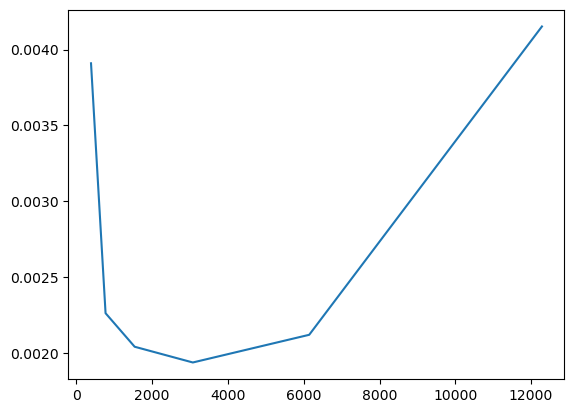

In [43]:
import time
times = []
sizes = [384, 768, 1536, 3072, 6144, 12288]
for bs in sizes:
    t0 = time.time()
    uq = u_q(get_i(y_hat, 0, bs=bs), get_i(y_hat, 1, bs=bs), GMM, debug=True)
    times.append(time.time() - t0)
plt.plot(sizes, times)
plt.show()


In [333]:
for name in names:
    print(f"mse : {mse_gradients[name].mean()}, nll : {nll_gradients[name].mean()}")

mse : -0.00030138809233903885, nll : -0.0004271512443665415
mse : 0.00033526954939588904, nll : 0.000518108019605279
mse : 2.3643107851967216e-05, nll : -0.0002450272149872035
mse : 9.314161434303969e-05, nll : -0.00033362951944582164
mse : -3.025284968316555e-05, nll : -0.000310779083520174
mse : -0.00012433109804987907, nll : -0.0013460299232974648
mse : 0.0004090542788617313, nll : -0.0006081417668610811
mse : -0.0013874778524041176, nll : -0.016633838415145874


## Training on Dist Loss

In [80]:
model = tru.build_baseline_model(mconfig, from_ckpt=False)#, ckpt_path=base_dir + '/testing_just_mse-ckpt.pt')

/tmp/ipykernel_112540/1088601492.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(kwargs["ckpt_path"], map_location=torch.device('cpu'))

In [82]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        total_loss = loss_fn(model(test_ds.X), test_ds.Y)
        return(total_loss / test_ds.Y.shape[0])

## Scratch

In [ ]:
n_samples = 3

ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, bs, (mask.sum(),))
    jx[mask] = torch.randint(0, bs, (mask.sum(),))
    mask = ix == jx

ix, jx

In [63]:
model, losses = vanilla_train(model, train_ds, loss_fn, tconfig)

Epoch [1/10], Train Loss: 0.0505, Test Loss: 0.0336
Epoch [2/10], Train Loss: 0.0204, Test Loss: 0.0393
Epoch [3/10], Train Loss: 0.0180, Test Loss: 0.0469
Epoch [4/10], Train Loss: 0.0170, Test Loss: 0.0483
Epoch [5/10], Train Loss: 0.0164, Test Loss: 0.0500
Saving Model
Epoch [6/10], Train Loss: 0.0160, Test Loss: 0.0531
Epoch [7/10], Train Loss: 0.0158, Test Loss: 0.0555
Epoch [8/10], Train Loss: 0.0155, Test Loss: 0.0577
Epoch [9/10], Train Loss: 0.0154, Test Loss: 0.0591
Epoch [10/10], Train Loss: 0.0152, Test Loss: 0.0607
Saving Model


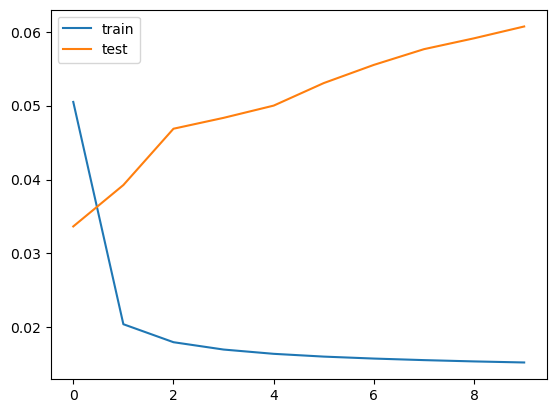

In [64]:
plt.plot(losses['train'], label='train')
plt.plot(losses['test'], label='test')
plt.legend()
plt.show()